In [1]:
%cd .. 

/home/ai_n_zag@lab.graphicon.ru/tmp/kolobok/ml


In [2]:
from pathlib import Path

import pandas as pd

In [17]:
def pop_first(arr: list[str]) -> str:
    return arr.pop(0)


def parse_ckpt_name(name: str) -> dict:
    name = name.split("_")
    model_name = pop_first(name)
    if model_name == "swin":
        model_name += f"_{pop_first(name)}"
        model_name += f"_{pop_first(name)}"

    score = float(pop_first(name))

    result = {
        "model_name": model_name,
        "score": score,
        "aug": "yes" if "aug" in name else "no",
        "clahe": "yes" if "clahe" in name else "no",
        "synthetic": "yes" if "synthetic" in name else "no",
    }

    return result


ckpt_dir = Path("checkpoints/depth")

data = []

for ckpt_path in ckpt_dir.iterdir():
    name = ckpt_path.stem

    model_name, metric, args = name.split("_", maxsplit=2)

    data.append(parse_ckpt_name(name))

df = pd.DataFrame(data)
df.sort_values("score", ascending=False)

,model_name,score,aug,clahe,synthetic
11,swin_v2_s,0.7977,no,no,yes
0,swin_v2_s,0.7839,yes,yes,no
6,swin_v2_s,0.7816,no,yes,no
1,swin_v2_s,0.7816,yes,yes,yes
13,swin_v2_s,0.7816,yes,no,no
22,densenet201,0.7816,yes,yes,no
10,swin_v2_s,0.7793,yes,no,yes
2,densenet201,0.7747,no,yes,yes
9,densenet201,0.7747,no,no,yes
8,swin_v2_s,0.7724,no,no,no


In [1]:
import torch
from torch import optim

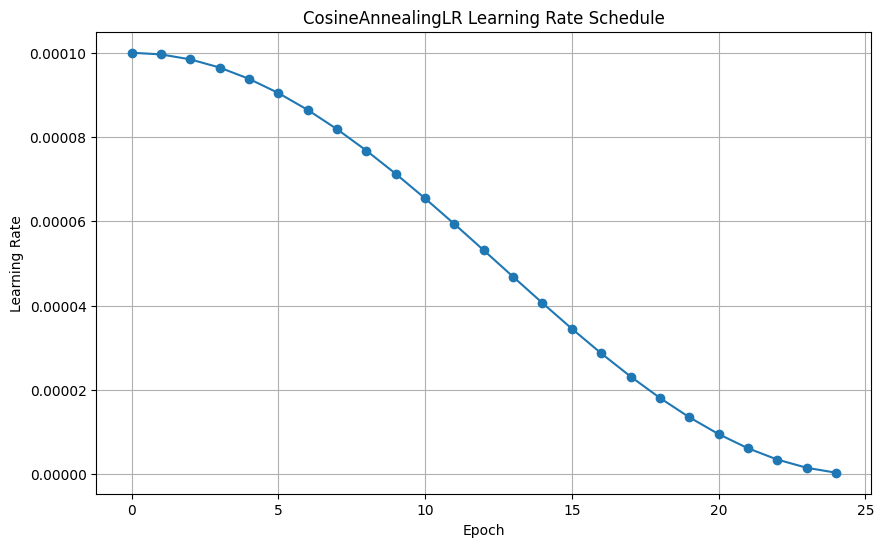

In [6]:
# plot learning rate schedule for CosineAnnealingLR
# optim.lr_scheduler.CosineAnnealingLR


import matplotlib.pyplot as plt
import numpy as np

# Create a simple model to demonstrate the scheduler
model = torch.nn.Linear(10, 1)
optimizer = optim.AdamW(model.parameters(), lr=1e-4)

# Create the scheduler
num_epochs = 25
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=num_epochs)

# Track learning rates
num_pts = num_epochs * 1
lrs = []
for epoch in range(num_pts):
    lrs.append(optimizer.param_groups[0]['lr'])
    scheduler.step()

# Plot the learning rate schedule
plt.figure(figsize=(10, 6))
plt.plot(range(num_pts), lrs, marker='o')
plt.title('CosineAnnealingLR Learning Rate Schedule')
plt.xlabel('Epoch')
plt.ylabel('Learning Rate')
plt.grid(True)

plt.show()


In [8]:
lrs[-2]

1.570841943568452e-06